# 1. Processing the data

This notebook turns the raw model files and ERA5 into the seasonal means that the other notebooks start from. It runs on JASMIN, once per variable.

| Step | From | To (under `SCRATCH`, then `DATA_DIR`) |
|---|---|---|
| 1. LESFMIP to monthly stores | one netCDF file per member | `monthly/lesfmip/<variable>/<model>_<variable>_<experiment>_interp_monthly.zarr` |
| 2. ERA5 to monthly means | hourly ERA5 analyses | `monthly/era5_<variable>.zarr`, on the LESFMIP grid |
| 3. Seasonal means | the monthly stores | `seasonal/lesfmip_<variable>.zarr` and `seasonal/era5_<variable>.zarr` |
| 4. Test sample | the monthly stores | `tests/data/*_sample.nc` in this repository |
| 5. Sea ice (once) | the sea-ice concentration files | `results/siconc/full/extent.zarr` and `climatology.zarr` |

**Where things are written.** Dask writes zarr stores from many workers at once, which the group workspaces do not support. So everything is written under `paths.SCRATCH` and moved to `paths.DATA_DIR` by hand (the last section has the commands). Everything that reads data looks in `DATA_DIR` first and then in `SCRATCH`, so a store can be used as soon as it is written.

Steps 1 and 2 take hours and only need running again for a new variable or new models; both skip what already exists. Sections marked (JASMIN) need the data there. Section 3 can also run on the small sample in `tests/data`, which is a quick way to see what each step does.

Each step prints what it made, with a **quick look** (a plain xarray plot, all its code here) before each method figure. Names end in their type: `_tree` (DataTree), `_ds` (Dataset), `_da` (DataArray), `_arr` (numpy array), `_df` (DataFrame).

## Setup

In [6]:
import sys
sys.path[:0] = ['..', '../../extant-functions']   # this repository (the extant package) and plotting_modules

import logging
import warnings
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from dask.distributed import wait
from plotting_modules import formatting, maps
from extant import config, loading, paths, preprocessing as pp, storage
from extant.logger import setup_logging
from extant.plots import methods

logger = setup_logging('extant', logging.INFO)
xr.set_options(display_expand_attrs=False, display_expand_data=False)

#(t): Dask warns about every large task graph; the graphs here are large on purpose
warnings.filterwarnings('ignore', message='.*Sending large graph of size.*', category=UserWarning)

from importlib.util import find_spec

from extant import convert, datatree, sea_ice
from extant.plots import sea_ice as sip

#(t): flox speeds up groupby/resample on dask (the seasonal means); xarray uses it automatically when installed
if find_spec('flox') is None:
    logger.warning('flox is not installed: pip install flox to speed up the seasonal means')

## Settings

`VARIABLE` is the CMIP name of the variable to process. Its units, and how to convert them, are in `config.VARIABLES`: temperature goes from K to °C, $T_{°C} = T_K - 273.15$, and precipitation from kg m⁻² s⁻¹ to mm day⁻¹, $P_{mm\,day^{-1}} = 86400\,P_{kg\,m^{-2}\,s^{-1}}$.

In [7]:
VARIABLE = 'tas'
var = config.VARIABLES[VARIABLE]
var

Variable(name='tas', long_name='Near-surface air temperature', units='°C', scale=1.0, offset=-273.15, era5_code='2t', era5_name='t2m', table='Amon')

In [8]:
#(t): Where this session reads from and writes to
print(f'reading raw LESFMIP from {paths.lesfmip_raw(VARIABLE)}')
print(f'writing to               {paths.SCRATCH}')
print(f'reading outputs from     {paths.DATA_DIR}, then {paths.SCRATCH}')

reading raw LESFMIP from /gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/Amon/tas
writing to               /work/scratch-pw4/aborow/ExtAnt
reading outputs from     /gws/ssde/j25b/leader_epesc/aborow/ExtAnt, then /work/scratch-pw4/aborow/ExtAnt


## Dask cluster (JASMIN)

The heavy steps run on a Dask Gateway cluster on JASMIN. `jasmin.stop_all(gateway)` stops every cluster left over from an earlier kernel.

In [9]:
#(t): Start a Dask Gateway cluster, or reuse the one already running, and send it the extant package
#(c): Re-run upload_package after editing anything in extant/: the workers run its functions
from extant import jasmin

gateway, cluster, client = jasmin.connect(n_workers=20, wait_for=6)
jasmin.upload_package(client)
client

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /_jasmin/proxy/dask-gateway/clusters/40abe25f4edb40858da7a5952f8264eb/status,


## 1. LESFMIP: member files to monthly stores (JASMIN)

The raw files are laid out as `<variable>/<experiment>/<model>/*.nc`, one file per member. Each model's members for one experiment are opened together and stacked along a new `member` dimension, labelled from the file names (`r1i1p1f1` and the like; `convert.member_from_path`). Only the area south of 40°S is kept.

First, which models have which experiments. Only models with at least `config.MIN_EXPERIMENTS` of the experiments are converted.

In [ ]:
#(t): Models with raw files for each experiment, the best-covered first
availability_df = convert.availability(VARIABLE, experiments=config.MAIN_EXPERIMENTS)
availability_df.assign(total=availability_df.sum(axis=1))

In [ ]:
convert_models = list(availability_df.index[availability_df.sum(axis=1) >= config.MIN_EXPERIMENTS])
convert_models

The stores left to make: each model and experiment with raw files and no store yet (in either place). Only the `config.GROUP` files are converted (`*_interp.nc`, the files on the common 2.5° grid). To make a store again, delete it first.

In [ ]:
todo = [(model, experiment) for model in convert_models for experiment in config.MAIN_EXPERIMENTS
        if availability_df.loc[model, experiment]
        and not storage.exists(paths.lesfmip_monthly(model, VARIABLE, experiment, config.GROUP))]
todo

### One store, step by step

The first store left: its files, one member's file before and after `convert.preprocess_member`, then all the members opened together. Nothing is saved here.

In [ ]:
model, experiment = todo[0]
files = convert.raw_files(VARIABLE, experiment, model)
files

In [ ]:
#(t): The member label read from each file's name
[convert.member_from_path(file) for file in files]

In [ ]:
#(t): One member's file as it is on disk
member_ds = xr.open_dataset(files[0])
member_ds

In [ ]:
#(t): After preprocess_member: only VARIABLE, south of 40°S, labelled with its member
convert.preprocess_member(member_ds, VARIABLE)

In [ ]:
%%time
#(t): All the members, stacked along member (lazily)
members_ds = convert.open_members(files, VARIABLE)
members_ds

In [ ]:
members_ds[VARIABLE].isel(member=0, time=0).plot();

### All of it

Every store left, one after the other. If one fails, the loop stops with its error.

In [ ]:
%%time
for model, experiment in todo:
    members_ds = convert.open_members(convert.raw_files(VARIABLE, experiment, model), VARIABLE)
    storage.save(members_ds, paths.lesfmip_monthly(model, VARIABLE, experiment, config.GROUP), consolidated=True)

A store that fails can be saved by hand without its broken files, then the loop re-run. For example, member 55 of historical GISS-E2-1-G has no time axis:

```python
files = convert.raw_files(VARIABLE, 'historical', 'GISS-E2-1-G')
files.pop(55)
storage.save(convert.open_members(files, VARIABLE),
             paths.lesfmip_monthly('GISS-E2-1-G', VARIABLE, 'historical', config.GROUP), consolidated=True)
```

## 2. ERA5: hourly files to monthly means (JASMIN)

Each month of hourly analyses is averaged on a worker (summing in float64), then regridded **conservatively** onto the LESFMIP 2.5° grid with xesmf, so each model grid cell gets the area-weighted mean of the ERA5 cells inside it. Each year is saved as its own store as soon as its twelve months are done, so an interrupted run picks up where it stopped. At the end the year stores are combined into one store.

ERA5 is kept on its own (standard) calendar. Its seasons are matched to the models' by their (year, season) labels in step 3, not by date.

In [10]:
#(t): Years already done: saved as a year store (an interrupted run), or in the combined store
years_dir = paths.era5_years_dir(VARIABLE)
done_years = [int(store.stem) for store in paths.find_all(years_dir, '*.zarr')]
if storage.exists(paths.era5_monthly(VARIABLE)):
    done_years += np.unique(storage.open_dataarray(paths.era5_monthly(VARIABLE)).time.dt.year).tolist()
done_years

21:36:46 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/monthly/era5_tas.zarr


[1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [11]:
todo_years = [year for year in range(config.ERA5_START_YEAR, 2025) if year not in done_years]
todo_years

[]

### The grid to regrid onto

One LESFMIP monthly store: they are all on the same 2.5° grid.

In [12]:
target_ds = storage.open_dataset(paths.lesfmip_monthly('CanESM5', VARIABLE, 'historical', config.GROUP))
target_ds

21:36:46 INFO    extant.storage | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_historical_interp_monthly.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


<xarray.Dataset> Size: 3GB
Dimensions:  (member: 65, time: 1980, lat: 20, lon: 144)
Coordinates:
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    height   float64 8B ...
Data variables:
    tas      (member, time, lat, lon) float64 3GB dask.array<chunksize=(5, 1980, 10, 144), meta=np.ndarray>

### One month, step by step

January of the first year left. Each hourly file is sorted south to north and cut at `convert.ERA5_LAT_MAX` (38°S), a little north of the LESFMIP edge, so the edge cells are fully covered.

In [14]:
todo_years

[]

In [13]:
example_files = convert.era5_files(VARIABLE, todo_years[0], 1)
len(example_files), example_files[0]

IndexError: list index out of range

In [ ]:
#(t): One hour, as the worker reads it
hour_ds = convert.era5_south(xr.open_dataset(example_files[0]))
hour_ds

The regridder needs the edges of every cell. They go half-way between the cell centres, clipped at ±90°: the LESFMIP row at 90°S would otherwise reach 91.25°S, past the pole.

In [ ]:
import cf_xarray  # noqa: F401  (adds .cf)
import xesmf

era5_grid_ds = hour_ds[['latitude', 'longitude']].rename(latitude='lat', longitude='lon').cf.add_bounds(['lat', 'lon'])
era5_grid_ds['lat_bounds'] = era5_grid_ds['lat_bounds'].clip(-90, 90)
era5_grid_ds

In [ ]:
target_grid_ds = target_ds[['lat', 'lon']].cf.add_bounds(['lat', 'lon'])
target_grid_ds['lat_bounds'] = target_grid_ds['lat_bounds'].clip(-90, 90)
target_grid_ds

In [ ]:
%%time
regridder = xesmf.Regridder(era5_grid_ds, target_grid_ds, 'conservative', periodic=True)
regridder

In [ ]:
%%time
#(t): The month's mean, worked out on a worker
month_da = xr.DataArray(client.submit(convert.era5_month_mean, example_files, var.era5_name).result(),
                        coords=[('lat', era5_grid_ds.lat.values), ('lon', era5_grid_ds.lon.values)])
month_da

In [ ]:
month_regridded_da = regridder(month_da)
month_regridded_da

In [ ]:
#(t): Before and after, on one colour scale
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
month_da.plot(ax=axes[0], vmin=float(month_da.min()), vmax=float(month_da.max()))
month_regridded_da.plot(ax=axes[1], vmin=float(month_da.min()), vmax=float(month_da.max()));

In [ ]:
#(t): The zonal means before and after
month_da.mean('lon').plot(label='ERA5 0.25°')
month_regridded_da.mean('lon').plot(marker='o', label='regridded 2.5°')
plt.legend();

### All of it

Every month left goes to the workers at once. Each year is regridded and saved as soon as its twelve months are back.

In [16]:
%%time
futures = {year: [client.submit(convert.era5_month_mean, convert.era5_files(VARIABLE, year, month), var.era5_name,
                                pure=False) for month in range(1, 13)]
           for year in todo_years}
for year in todo_years:
    year_da = xr.DataArray(np.stack(client.gather(futures[year])), dims=('time', 'lat', 'lon'),
                           coords={'time': pd.date_range(f'{year}-01-01', periods=12, freq='MS'),
                                   'lat': month_da.lat, 'lon': month_da.lon})
    storage.save(regridder(year_da).astype('float32').rename(VARIABLE), years_dir / f'{year}.zarr')

CPU times: user 7 μs, sys: 0 ns, total: 7 μs
Wall time: 12.2 μs


In [17]:
#(t): The year stores (and the combined store, if there is one) joined into one store; the year stores deleted
era5_monthly_da = convert.combine_era5_years(VARIABLE)
era5_monthly_da

21:37:48 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/monthly/era5_tas.zarr
21:37:54 INFO    extant.storage | writing DataArray (time: 552, lat: 20, lon: 144) to /work/scratch-pw4/aborow/ExtAnt/monthly/era5_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


21:37:55 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/monthly/era5_tas.zarr
21:37:55 INFO    extant.convert | ERA5 tas: {'time': 552, 'lat': 20, 'lon': 144} saved, 0 year stores removed


<xarray.DataArray 'tas' (time: 552, lat: 20, lon: 144)> Size: 6MB
244.8 244.9 245.2 245.7 246.2 246.8 ... 290.3 290.5 290.5 290.0 289.3 291.2
Coordinates:
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-12-01
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
Attributes: (1)

In [20]:
era5_monthly_da

<xarray.DataArray 'tas' (time: 552, lat: 20, lon: 144)> Size: 6MB
244.8 244.9 245.2 245.7 246.2 246.8 ... 290.3 290.5 290.5 290.0 289.3 291.2
Coordinates:
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2024-12-01
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
Attributes: (1)

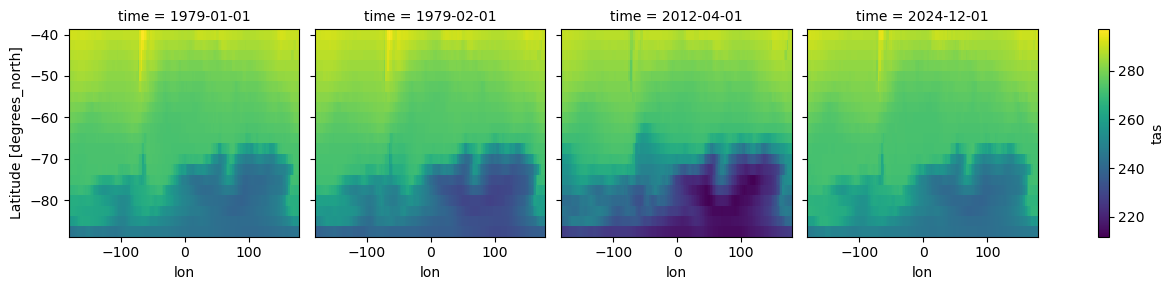

In [21]:
era5_monthly_da.isel(time=[0, 1, 399, -1]).plot(col='time')

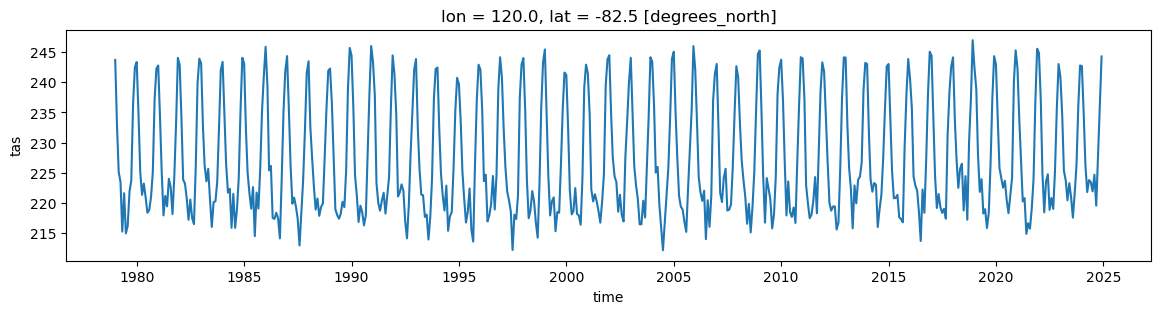

In [18]:
era5_monthly_da.sel(**config.POINT).plot(figsize=(14, 3));

## 3. Monthly to seasonal means

### Open the monthly data

Run **one** of the next two sections. Both leave the same variables: `lesfmip_tree`, monthly LESFMIP as a DataTree laid out `/<model>/<experiment>`, and `era5_monthly_da`, both in the units of the raw files.

#### Sample data

The 3×3 block of grid cells around `config.POINT` in `tests/data`: two models, every experiment.

In [24]:
lesfmip_tree = loading.open_lesfmip_sample(experiments=config.MAIN_EXPERIMENTS)
era5_monthly_da = loading.open_era5_sample()
lesfmip_tree

21:39:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-GHG_sample.nc as /CanESM5/hist-GHG
21:39:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-aer_sample.nc as /CanESM5/hist-aer
21:39:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-nat_sample.nc as /CanESM5/hist-nat
21:39:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-totalO3_sample.nc as /CanESM5/hist-totalO3
21:39:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_historical_sample.nc as /CanESM5/historical
21:39:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/HadGEM3-GC31-LL_hist-GHG_sample.nc as /HadGEM3-GC31-LL/hist-GHG
21:39:47 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/HadGEM3-GC31-LL_hist-aer_sample.nc as /HadGEM3-GC31-LL/hist-aer
21:39:47 IN

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (member: 50, time: 2052, lat: 3, lon: 3)
│   │       Coordinates:
│   │         * lon      (lon) float64 24B 117.5 120.0 122.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B 2.0
│   │         * member   (member) <U9 2kB 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p1f1' 'r9i1p2f1'
│   │         * lat      (lat) float64 24B -85.0 -82.5 -80.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 4MB 243.9 244.2 ... 247.6 248.2
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (member: 30, time: 2052, lat: 3, lon: 3)
│   │       Coordinates:
│   │         * lon      (lon) float64 24B 117.5 120.0 122.5
│   │         * member   (member) <U9 1kB 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p1f1' 'r9i1p2f1'
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 24B -85.0 -82.5 -80.0
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 2MB 242.5 242.8 ... 241.3 241.9
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (member: 50, time: 2052, lat: 3, lon: 3)
│   │       Coordinates:
│   │         * lon      (lon) float64 24B 117.5 120.0 122.5
│   │         * member   (member) <U9 2kB 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p1f1' 'r9i1p2f1'
│   │         * lat      (lat) float64 24B -85.0 -82.5 -80.0
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B 2.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 4MB 244.3 244.5 ... 244.3 244.9
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (member: 10, time: 2052, lat: 3, lon: 3)
│   │       Coordinates:
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 24B -85.0 -82.5 -80.0
│   │         * lon      (lon) float64 24B 117.5 120.0 122.5
│   │           height   float64 8B 2.0
│   │         * member   (member) <U9 360B 'r10i1p1f1' 'r1i1p1f1' ... 'r8i1p1f1' 'r9i1p1f1'
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 739kB 242.7 243.2 ... 244.5 245.1
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, time: 1980, lat: 3, lon: 3)
│           Coordinates:
│             * lon      (lon) float64 24B 117.5 120.0 122.5
│             * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│             * member   (member) <U9 2kB 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p1f1' 'r9i1p2f1'
│             * lat      (lat) float64 24B -85.0 -82.5 -80.0
│               height   float64 8B 2.0
│           Data variables:
│               tas      (member, time, lat, lon) float64 9MB 243.9 244.3 ... 244.6 245.2
└── Group: /HadGEM3-GC31-LL
    ├── Group: /HadGEM3-GC31-LL/hist-GHG
    │       Dimensions:  (member: 55, time: 2052, lat: 3, lon: 3)
    │       Coordinates:
    │         * member   (member) <U9 2kB 'r11i1p1f3' 'r12i1p1f3' ... 'r5i1p1f3' 'r60i1p1f3'
    │         * lat      (lat) float64 24B -85.0 -82.5 -80.0
    │         * time     (time) object 16kB 1850-01-16 00:00:00 ... 2020-12-16 00:00:00
    │         * lon      (lon) float64 24B 117.5 120.0 122.5
    │           height   float64 8B 1.5
    │       Data variables:
    │           tas      (member, time, lat, lon) float32 4MB 249.0 249.0 ... 255.0 255.1
    ├── Group: /HadGEM3-GC31-LL/hist-aer
    │       Dimensions:  (member: 55, time: 2052, lat: 3, lon: 3)
    │       Coordinates:
    │         * lon      (lon) float64 24B 117.5 120.0 122.5
    │         * lat      (lat) float64 24B -85.0 -82.5 -80.0
    │         * time     (time) object 16kB 1850-01-16 00:00:00 ... 2020-12-16 00:00:00
    │         * member   (member) <U9 2kB 'r11i1p1f3' 'r12i1p1

#### Full data (JASMIN)

The `config.N_MODELS` models with stores for the most experiments.

In [25]:
#(t): Which models have a monthly store for which experiment
stores_df = loading.store_table(VARIABLE, groups=[config.GROUP])
stores_df

21:39:48 INFO    extant.loading | 112 monthly tas stores in /work/scratch-pw4/aborow/LESFMIP/monthly_v2


experiment,hist-GHG,hist-aer,hist-lu,hist-nat,hist-sol,hist-totalO3,hist-volc,historical
model,,,,,,,,
ACCESS-ESM1-5,1,1,1,1,1,0,1,1
BCC-CSM2-MR,1,1,1,1,0,0,0,1
CESM2,1,1,1,1,0,0,0,1
CMCC-CM2-SR5,1,1,1,0,0,0,1,1
CNRM-CM6-1,1,1,1,1,0,0,0,1
CanESM5,1,1,1,1,1,1,1,1
E3SM-2-0,1,1,1,1,0,0,0,1
FGOALS-g3,1,1,1,1,0,0,0,1
GISS-E2-1-G,1,1,1,1,1,1,1,1


In [26]:
models = loading.models_with_most_experiments(stores_df, config.N_MODELS, experiments=config.MAIN_EXPERIMENTS)
lesfmip_tree = loading.open_lesfmip_monthly(VARIABLE, models=models, experiments=config.MAIN_EXPERIMENTS,
                                            groups=[config.GROUP])
era5_monthly_da = loading.open_era5_monthly(VARIABLE)
lesfmip_tree

21:39:48 INFO    extant.loading | 112 monthly tas stores in /work/scratch-pw4/aborow/LESFMIP/monthly_v2
21:39:48 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-GHG_interp_monthly.zarr as /CanESM5/hist-GHG
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-aer_interp_monthly.zarr as /CanESM5/hist-aer
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-nat_interp_monthly.zarr as /CanESM5/hist-nat
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-totalO3_interp_monthly.zarr as /CanESM5/hist-totalO3
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_historical_interp_monthly.zarr as /CanESM5/historical
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/GISS-E2-1-G_tas_hist-GHG_interp_monthly.zarr as /GISS-E2-1

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-GHG_interp_monthly.zarr as /HadGEM3-GC31-LL/hist-GHG
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-aer_interp_monthly.zarr as /HadGEM3-GC31-LL/hist-aer
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-nat_interp_monthly.zarr as /HadGEM3-GC31-LL/hist-nat
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-totalO3_interp_monthly.zarr as /HadGEM3-GC31-LL/hist-totalO3
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_historical_interp_monthly.zarr as /HadGEM3-GC31-LL/historical
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MIROC6_tas_hist-GHG_interp_monthly.zarr as /MIROC6/hist-GHG
21:39:49 INFO    extan

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-GHG_interp_monthly.zarr as /MPI-ESM1-2-LR/hist-GHG
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-aer_interp_monthly.zarr as /MPI-ESM1-2-LR/hist-aer
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-nat_interp_monthly.zarr as /MPI-ESM1-2-LR/hist-nat
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_hist-totalO3_interp_monthly.zarr as /MPI-ESM1-2-LR/hist-totalO3
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/MPI-ESM1-2-LR_tas_historical_interp_monthly.zarr as /MPI-ESM1-2-LR/historical
21:39:49 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/NorESM2-LM_tas_hist-GHG_interp_monthly.zarr as /NorESM2-LM/hist-GHG
21:39:49 INFO    extant.loading | 

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

21:39:49 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/monthly/era5_tas.zarr


<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (lon: 144, member: 50, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (lon: 144, member: 30, time: 2052, lat: 20)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 709MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (lon: 144, member: 50, lat: 20, time: 2052)
│   │       Coordinates:
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │           height   float64 8B ...
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 1GB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (time: 2052, lat: 20, member: 10, lon: 144)
│   │       Coordinates:
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2020-12-16 12:00:00
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │           height   float64 8B ...
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │       Data variables:
│   │           tas      (member, time, lat, lon) float32 236MB dask.array<chunksize=(5, 2052, 10, 144), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, time: 1980, lat: 20, lon: 144)
│           Coordinates:
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│               height   float64 8B ...
│           Data variables:
│               tas      (member, time, lat, lon) float64 3GB dask.array<chunksize=(5, 1980, 10, 144), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (member: 45, time: 1980, lat: 20, lon: 144)
│   │       Coordinates:
│   │         * member   (member) object 360B 'r10i1p1f2' 'r10i1p3f1' ... 'r9i1p3f1'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
│   │           height   float64 8B ...
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │      

### What is there

How many members each model ran for each experiment. A model's members differ only in their initial conditions, so the spread across them is the model's internal variability, and the more members, the better the forced response and the variability are pinned down.

In [27]:
#(t): Members per model (rows) and experiment (columns)
member_counts_df = pd.Series({(node.parent.name, node.name): node.sizes['member'] for node in lesfmip_tree.leaves})
member_counts_df = member_counts_df.unstack()[[e for e in config.MAIN_EXPERIMENTS if e in member_counts_df.index.levels[1]]]
member_counts_df

,hist-nat,hist-aer,hist-totalO3,hist-GHG,historical
CanESM5,50,30,10,50,65
GISS-E2-1-G,20,45,40,45,63
HadGEM3-GC31-LL,60,55,50,55,55
MIROC6,50,10,10,50,50
MPI-ESM1-2-LR,30,30,30,30,51
NorESM2-LM,23,23,20,23,43


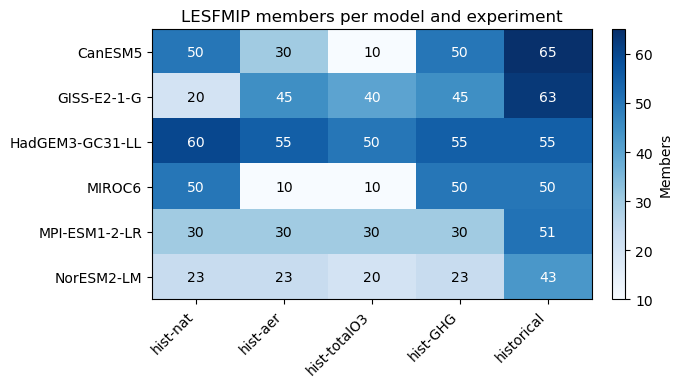

In [28]:
fig, ax = methods.member_count_heatmap(member_counts_df, title='LESFMIP members per model and experiment')

In [29]:
#(t): Every node's dimensions, size in memory and chunking
pd.DataFrame.from_dict({node.path: datatree.coord_info(node.to_dataset()) for node in lesfmip_tree.leaves},
                       orient='index')

size                 chunk                 \
                              member  time lat  lon member  time lat  lon   
/CanESM5/hist-GHG                 50  2052  20  144      5  2052  10  144   
/CanESM5/hist-aer                 30  2052  20  144      5  2052  10  144   
/CanESM5/hist-nat                 50  2052  20  144      5  2052  10  144   
/CanESM5/hist-totalO3             10  2052  20  144      5  2052  10  144   
/CanESM5/historical               65  1980  20  144      5  1980  10  144   
/GISS-E2-1-G/hist-GHG             45  1980  20  144      5  1980  10  144   
/GISS-E2-1-G/hist-aer             45  1980  20  144      5  1980  10  144   
/GISS-E2-1-G/hist-nat             20  1980  20  144      5  1980  10  144   
/GISS-E2-1-G/hist-totalO3         40  1980  20  144      5  1980  10  144   
/GISS-E2-1-G/historical           63  1980  20  144      5  1980  10  144   
/HadGEM3-GC31-LL/hist-GHG         55  2052  20  144      5  2052  10  144   
/HadGEM3-GC31-LL/hist-aer         55  2052  20  144      5  2052  10  144   
/HadGEM3-GC31-LL/hist-nat         60  2052  20  144      5  2052  10  144   
/HadGEM3-GC31-LL/hist-totalO3     50  2052  20  144      5  2052  10  144   
/HadGEM3-GC31-LL/historical       55  1980  20  144      5  1980  10  144   
/MIROC6/hist-GHG                  50  2052  20  144      5  2052  10  144   
/MIROC6/hist-aer                  10  2052  20  144      5  2052  10  144   
/MIROC6/hist-nat                  50  2052  20  144      5  2052  10  144   
/MIROC6/hist-totalO3              10  2052  20  144      5  2052  10  144   
/MIROC6/historical                50  1980  20  144      5  1980  10  144   
/MPI-ESM1-2-LR/hist-GHG           30  1980  20  144      5  1980  10  144   
/MPI-ESM1-2-LR/hist-aer           30  1980  20  144      5  1980  10  144   
/MPI-ESM1-2-LR/hist-nat           30  1980  20  144      5  1980  10  144   
/MPI-ESM1-2-LR/hist-totalO3       30  1980  20  144      5  1980  10  144   
/MPI-ESM1-2-LR/historical         51  1980  20  144      5  1980  10  144   
/NorESM2-LM/hist-GHG              23  2052  20  144      5  2052  10  144   
/NorESM2-LM/hist-aer              23  2052  20  144      5  2052  10  144   
/NorESM2-LM/hist-nat              23  2052  20  144      5  2052  10  144   
/NorESM2-LM/hist-totalO3          20  2052  20  144      5  2052  10  144   
/NorESM2-LM/historical            43  1980  20  144      5  1980  10  144   

                              memory                       
                              mbytes chunk_mbytes nchunks  
/CanESM5/hist-GHG               1127         56.4      20  
/CanESM5/hist-aer                676         56.4      12  
/CanESM5/hist-nat               1127         56.4      20  
/CanESM5/hist-totalO3            225         56.4       4  
/CanESM5/historical             2827        108.8      26  
/GISS-E2-1-G/hist-GHG            978         54.4      18  
/GISS-E2-1-G/hist-aer            978         54.4      18  
/GISS-E2-1-G/hist-nat            435         54.4       8  
/GISS-E2-1-G/hist-totalO3        870         54.4      16  
/GISS-E2-1-G/historical         1370         54.4      26  
/HadGEM3-GC31-LL/hist-GHG       1239         56.4      22  
/HadGEM3-GC31-LL/hist-aer       1239         56.4      22  
/HadGEM3-GC31-LL/hist-nat       1352         56.4      24  
/HadGEM3-GC31-LL/hist-totalO3   1127         56.4      20  
/HadGEM3-GC31-LL/historical     1196         54.4      22  
/MIROC6/hist-GHG                1127         56.4      20  
/MIROC6/hist-aer                 225         56.4       4  
/MIROC6/hist-nat                1127         56.4      20  
/MIROC6/hist-totalO3             225         56.4       4  
/MIROC6/historical              1087         54.4      20  
/MPI-ESM1-2-LR/hist-GHG          652         54.4      12  
/MPI-ESM1-2-LR/hist-aer          652         54.4      12  
/MPI-ESM1-2-LR/hist-nat          652         54.4      12  
/MPI-ESM1-2-LR/hist-totalO3      652         54.4      12  
/MPI-ES

In [30]:
#(t): Two months of one member, to see the domain (everything south of 40°S)
months_da = pp.to_analysis_units(lesfmip_tree[config.PLOT_SEL['model']][config.PLOT_SEL['experiment']].to_dataset()
                                 .isel(member=0, time=[0, 6]), VARIABLE)[VARIABLE].load()
print(months_da)

<xarray.DataArray 'tas' (time: 2, lat: 20, lon: 144)> Size: 23kB
-23.69 -23.48 -23.29 -23.11 -22.94 -22.77 ... 12.15 11.73 10.99 10.71 12.07
Coordinates:
    member   <U9 36B 'r10i1p1f1'
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * time     (time) object 16B 1850-01-16 12:00:00 1850-07-16 12:00:00
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0


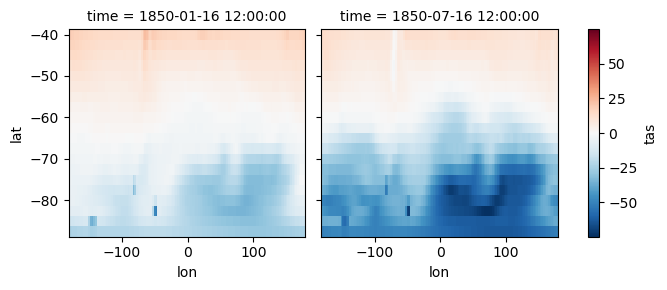

In [31]:
#(t): Quick look: the two months on the plain lat-lon grid
months_da.plot(x='lon', y='lat', col='time');

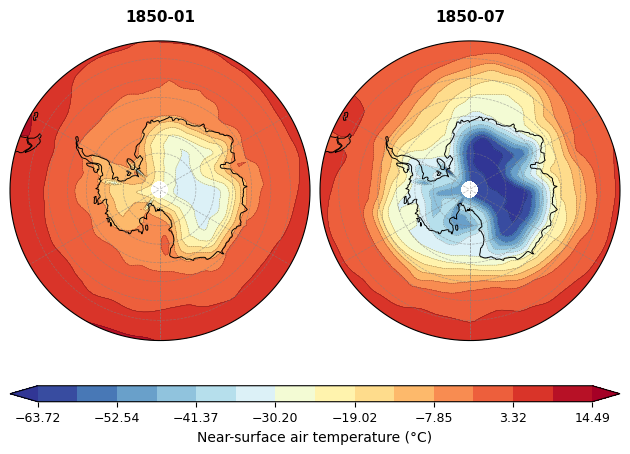

In [32]:
levels = np.linspace(float(months_da.quantile(0.02)), float(months_da.quantile(0.98)), 15)
panels = maps.polar_grid(months_da, col_dim='time', levels=levels, cmap='RdYlBu_r',
                         label_fmt={'time': lambda t: str(t)[:7]}, cbar_label=var.label, tag=False)

### How a seasonal mean is made

Each season is the mean of its three monthly means (each month counts equally, whatever its length):

$$
\bar{x}_{\mathrm{DJF},\,y} = \tfrac{1}{3}\left(x_{\mathrm{Dec}\,y} + x_{\mathrm{Jan}\,y+1} + x_{\mathrm{Feb}\,y+1}\right),
\qquad
\bar{x}_{\mathrm{MAM},\,y} = \tfrac{1}{3}\left(x_{\mathrm{Mar}\,y} + x_{\mathrm{Apr}\,y} + x_{\mathrm{May}\,y}\right), \ \ldots
$$

so DJF is labelled by the year of its December, and a "year" runs from March to the next February. Seasons with fewer than three months are dropped (the January–February stub at the start of a record), and so is any year without all four seasons. Every experiment is first cut at the end of 2014, where historical ends, so the record ends with DJF 2013 and "the final 21 years" are the same years in every experiment. The time axis is then split into `year` × `season` (`pp.split_time`), so that a rolling window moves through the years of one season.

The figure: one member at `config.POINT`, monthly means (grey) and the seasonal means made from them.

In [33]:
#(t): One member at the example point: monthly (in analysis units) on time, and its seasonal means on (year, season)
point_monthly_da = pp.to_analysis_units(lesfmip_tree[config.PLOT_SEL['model']][config.PLOT_SEL['experiment']]
                                        .to_dataset().sel(**config.POINT), VARIABLE)[VARIABLE].isel(member=0).load()
point_seasonal_da = pp.seasonal_means(point_monthly_da.sel(time=slice(None, config.LAST_MONTH)))
print(point_monthly_da, '\n')
print(point_seasonal_da)

<xarray.DataArray 'tas' (time: 1980)> Size: 8kB
-28.51 -41.32 -49.69 -52.19 -52.74 -56.78 ... -56.18 -57.65 -50.14 -35.02 -23.87
Coordinates:
    lon      float64 8B 120.0
    lat      float64 8B -82.5
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    member   <U9 36B 'r10i1p1f1' 

<xarray.DataArray 'tas' (year: 164, season: 4)> Size: 3kB
-33.05 -59.62 -51.54 -49.37 -33.0 -59.67 ... -47.03 -29.38 -58.4 -53.74 -48.39
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
    lon      float64 8B 120.0
    lat      float64 8B -82.5
    member   <U9 36B 'r10i1p1f1'


In [34]:
#(t): Check by hand: DJF 1990 is the mean of December 1990, January 1991 and February 1991
months_arr = point_monthly_da.sel(time=slice('1990-12', '1991-02')).values
print('Dec, Jan, Feb:', months_arr.round(3), ' mean:', months_arr.mean().round(3))
print('DJF 1990:     ', point_seasonal_da.sel(year=1990, season='DJF').values.round(3))

Dec, Jan, Feb: [-28.574 -27.196 -39.028]  mean: -31.599
DJF 1990:      -31.599


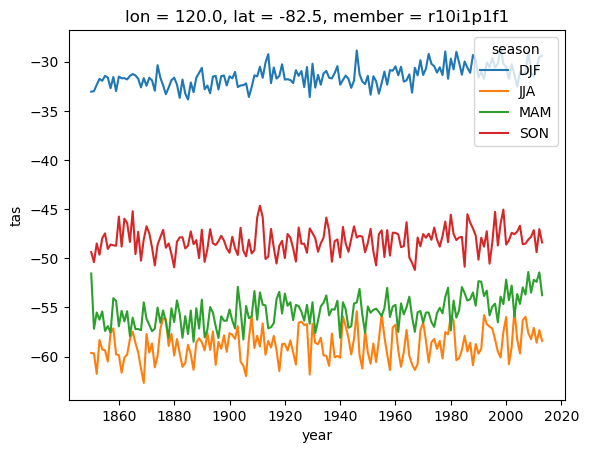

In [35]:
#(t): Quick look: the seasonal means, one line per season
point_seasonal_da.plot.line(x='year', hue='season');

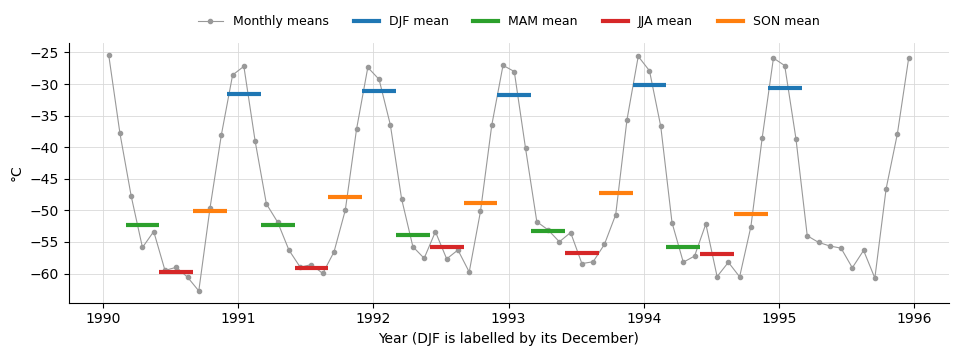

In [36]:
fig, ax = methods.seasonal_mean_demo(point_monthly_da, point_seasonal_da, slice(1990, 1995), units=var.units)

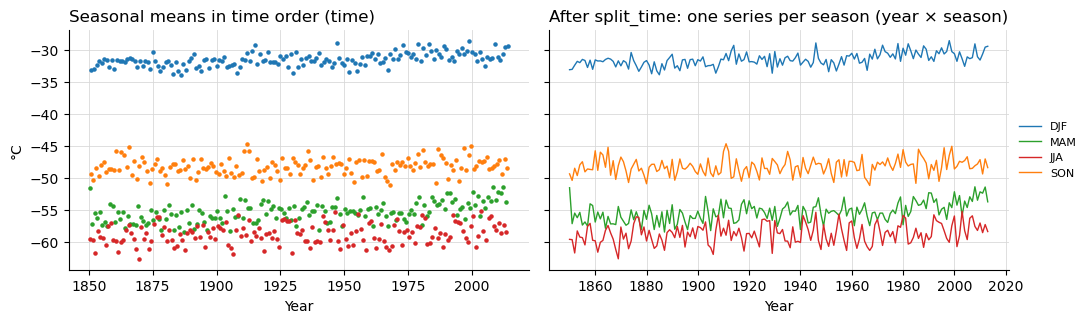

In [37]:
#(t): The same seasonal means, before and after splitting time into year x season
fig, axes = methods.year_season_demo(point_seasonal_da, units=var.units)

### All of it

`pp.seasonal_tree` runs these steps on every model and experiment, and `pp.seasonal_era5` on ERA5, which it also puts on the LESFMIP grid (`pp.match_grid`) and starts in 1979 (`config.ERA5_START_YEAR`), the start of the satellite era. Both are lazy: nothing is computed until the result is saved or loaded.

In [38]:
lesfmip_season_tree = pp.seasonal_tree(lesfmip_tree, VARIABLE)
era5_seasonal_da = pp.seasonal_era5(era5_monthly_da, VARIABLE, like=lesfmip_season_tree)
lesfmip_season_tree

<xarray.DataTree>
Group: /
├── Group: /CanESM5
│   ├── Group: /CanESM5/hist-GHG
│   │       Dimensions:  (member: 50, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 378MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-aer
│   │       Dimensions:  (member: 30, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 240B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 227MB dask.array<chunksize=(30, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-nat
│   │       Dimensions:  (member: 50, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 400B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 378MB dask.array<chunksize=(50, 4, 144, 164, 4), meta=np.ndarray>
│   ├── Group: /CanESM5/hist-totalO3
│   │       Dimensions:  (member: 10, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│   │         * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│   │         * member   (member) object 80B 'r10i1p1f1' 'r1i1p1f1' ... 'r9i1p1f1'
│   │       Data variables:
│   │           tas      (member, lat, lon, year, season) float32 76MB dask.array<chunksize=(10, 4, 144, 164, 4), meta=np.ndarray>
│   └── Group: /CanESM5/historical
│           Dimensions:  (member: 65, lat: 20, lon: 144, year: 164, season: 4)
│           Coordinates:
│             * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│             * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│             * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
│             * member   (member) object 520B 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p2f1'
│             * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
│           Data variables:
│               tas      (member, lat, lon, year, season) float32 491MB dask.array<chunksize=(65, 4, 144, 164, 4), meta=np.ndarray>
├── Group: /GISS-E2-1-G
│   ├── Group: /GISS-E2-1-G/hist-GHG
│   │       Dimensions:  (member: 45, lat: 20, lon: 144, year: 164, season: 4)
│   │       Coordinates:
│   │         * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
│   │         * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
│   │         * me

In [39]:
#(t): ERA5's seasonal means, on (year, season, lat, lon)
era5_seasonal_da

<xarray.DataArray 'tas' (lat: 20, lon: 144, year: 45, season: 4)> Size: 2MB
dask.array<chunksize=(10, 72, 15, 4), meta=np.ndarray>
Coordinates:
  * year     (year) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023
  * season   (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5

### Save (JASMIN)

Writing computes everything, in parallel on the cluster. The other notebooks then open these two stores in seconds.

In [40]:
%%time
storage.save(lesfmip_season_tree, paths.seasonal('lesfmip', VARIABLE))
storage.save(era5_seasonal_da, paths.seasonal('era5', VARIABLE))

21:39:56 INFO    extant.storage | writing DataTree of 30 nodes to /work/scratch-pw4/aborow/ExtAnt/seasonal/lesfmip_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `<U3` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by

21:40:36 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/seasonal/lesfmip_tas.zarr
21:40:36 INFO    extant.storage | writing DataArray (lat: 20, lon: 144, year: 45, season: 4) to /work/scratch-pw4/aborow/ExtAnt/seasonal/era5_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

21:40:37 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/seasonal/era5_tas.zarr
CPU times: user 1.12 s, sys: 386 ms, total: 1.51 s
Wall time: 40.9 s


PosixPath('/work/scratch-pw4/aborow/ExtAnt/seasonal/era5_tas.zarr')

In [41]:
#(t): Reopen what was saved, for the checks below
seasonal_path = paths.find(paths.seasonal('lesfmip', VARIABLE))
print(f'reading {seasonal_path}')
lesfmip_season_tree = xr.open_datatree(seasonal_path, engine='zarr', chunks={})
era5_seasonal_da = storage.open_dataarray(paths.seasonal('era5', VARIABLE))

reading /work/scratch-pw4/aborow/ExtAnt/seasonal/lesfmip_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

21:40:37 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/seasonal/era5_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


### Checks

The seasonal means at the example point: the members of one model (grey) and ERA5 (black) over the years they share. ERA5 should sit among the members; a constant offset would be a mean-state bias of the model, which the ERA5 notebook tests properly.

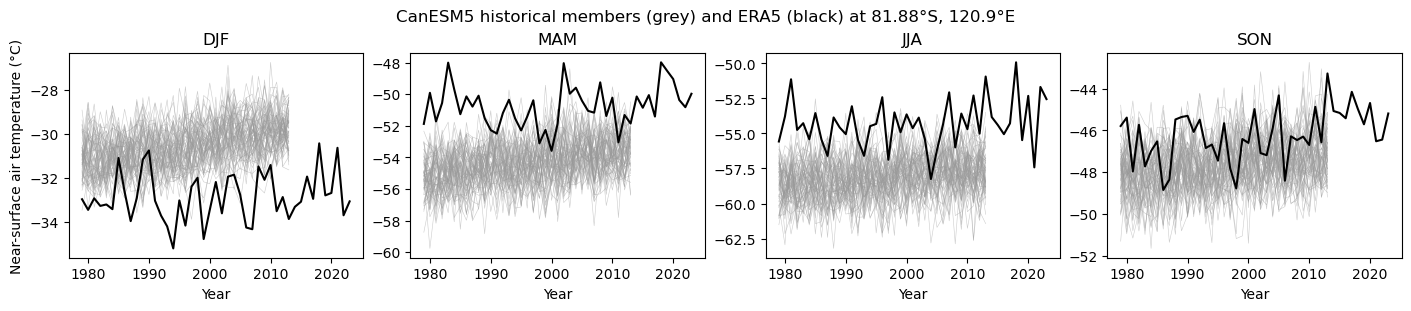

In [42]:
#(t): ERA5 among one model's historical members at the example point, every season
point_members_da = lesfmip_season_tree[config.PLOT_SEL['model']][config.PLOT_SEL['experiment']][VARIABLE].sel(**config.POINT)
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharex=True, layout='constrained')
for ax, season in zip(axes, ['DJF', 'MAM', 'JJA', 'SON']):
    members_da = point_members_da.sel(season=season, year=slice(config.ERA5_START_YEAR, None))
    ax.plot(members_da.year, members_da.transpose('year', 'member'), color='0.6', lw=0.4, alpha=0.5)
    ax.plot(era5_seasonal_da.year, era5_seasonal_da.sel(**config.POINT).sel(season=season), color='k', lw=1.5)
    ax.set_title(season)
    ax.set_xlabel('Year')
axes[0].set_ylabel(var.label)
fig.suptitle(f"{config.PLOT_SEL['model']} {config.PLOT_SEL['experiment']} members (grey) and ERA5 (black) "
             f"at {formatting.format_latlon(config.POINT)}");

## 4. Test sample (JASMIN)

The 3×3 block of grid cells around `config.POINT`, from two models with every experiment and from ERA5, saved to `tests/data`. The tests and the sample sections of every notebook use it. It is temperature only, so only re-run this for `tas`.

In [43]:
sample_tree = loading.open_lesfmip_monthly(VARIABLE, models=['CanESM5', 'HadGEM3-GC31-LL'], groups=[config.GROUP])
written = loading.write_sample(sample_tree, loading.open_era5_monthly(VARIABLE))
[f'{f.name}: {f.stat().st_size / 1e6:.1f} MB' for f in written]

21:40:39 INFO    extant.loading | 112 monthly tas stores in /work/scratch-pw4/aborow/LESFMIP/monthly_v2
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-GHG_interp_monthly.zarr as /CanESM5/hist-GHG
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-aer_interp_monthly.zarr as /CanESM5/hist-aer
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-lu_interp_monthly.zarr as /CanESM5/hist-lu
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-nat_interp_monthly.zarr as /CanESM5/hist-nat
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-sol_interp_monthly.zarr as /CanESM5/hist-sol
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/CanESM5_tas_hist-totalO3_interp_monthly.zarr as /CanESM5/hist-totalO3
21

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-totalO3_interp_monthly.zarr as /HadGEM3-GC31-LL/hist-totalO3
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_hist-volc_interp_monthly.zarr as /HadGEM3-GC31-LL/hist-volc
21:40:39 INFO    extant.loading | opening /work/scratch-pw4/aborow/LESFMIP/monthly_v2/HadGEM3-GC31-LL_tas_historical_interp_monthly.zarr as /HadGEM3-GC31-LL/historical
21:40:39 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/monthly/era5_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

['CanESM5_hist-GHG_sample.nc: 3.7 MB',
 'CanESM5_hist-aer_sample.nc: 2.2 MB',
 'CanESM5_hist-lu_sample.nc: 5.0 MB',
 'CanESM5_hist-nat_sample.nc: 3.7 MB',
 'CanESM5_hist-sol_sample.nc: 3.7 MB',
 'CanESM5_hist-totalO3_sample.nc: 0.8 MB',
 'CanESM5_hist-volc_sample.nc: 3.7 MB',
 'CanESM5_historical_sample.nc: 9.3 MB',
 'HadGEM3-GC31-LL_hist-GHG_sample.nc: 4.1 MB',
 'HadGEM3-GC31-LL_hist-aer_sample.nc: 4.1 MB',
 'HadGEM3-GC31-LL_hist-lu_sample.nc: 5.0 MB',
 'HadGEM3-GC31-LL_hist-nat_sample.nc: 4.5 MB',
 'HadGEM3-GC31-LL_hist-sol_sample.nc: 3.7 MB',
 'HadGEM3-GC31-LL_hist-totalO3_sample.nc: 3.7 MB',
 'HadGEM3-GC31-LL_hist-volc_sample.nc: 3.7 MB',
 'HadGEM3-GC31-LL_historical_sample.nc: 4.0 MB',
 'era5_sample.nc: 0.0 MB']

## 5. Sea ice (JASMIN)

The figures mark the sea-ice edge, as Bracegirdle et al. (2024, *npj Clim. Atmos. Sci.* 7, 276) do: on maps as the 15% contour of the ensemble-mean concentration, and on the zonal-mean figures as an **equivalent latitude**, the latitude the edge would be at if the ice and the continent it surrounds were a cap round the pole. The area of the Earth south of latitude $\varphi$ is

$$
A(\varphi) = 2\pi R^2\,(1 + \sin\varphi),
$$

so the edge is at the latitude whose cap holds the sea-ice extent and the continent together:

$$
\varphi_{\mathrm{eq}} = \arcsin\left(\frac{\mathrm{SIE} + A_{\mathrm{continent}}}{2\pi R^2} - 1\right).
$$

- **Sea-ice extent** (SIE): the area of the cells with at least 15% ice, worked out every month and averaged into seasons, for every member.
- **The continent**: the land south of 60°S, i.e. the cells where the ocean model gives no concentration. With no sea ice at all, $\varphi_{\mathrm{eq}}$ is about 71°S.

Each model keeps its own edge; nothing is averaged across models. Unlike the paper, which uses each model's own ocean grid, everything here is on the common 2.5° grid of the interpolated files.

This section runs once, whatever `VARIABLE` is. It converts the concentration (`siconc`) of the models analysed, then saves each member's seasonal extent and the ensemble-mean concentration over the final `config.WINDOW` years, as `results/siconc/full/extent.zarr` and `climatology.zarr`. Notebook 04 reads them. The code is in `extant/sea_ice.py`.

**Where the files are.** `paths.lesfmip_raw('siconc')`, built from the variable's CMIP table in `config.VARIABLES`. The table (`SImon`) is a guess: change it there if the interpolated sea-ice files are somewhere else.

In [44]:
#(t): The models analysed (those in the seasonal store of VARIABLE), and which of them have sea-ice files
SEA_ICE = 'siconc'
ice_models = list(loading.open_seasonal(VARIABLE).children)
print(f'reading raw sea ice from {paths.lesfmip_raw(SEA_ICE)}')
ice_availability_df = convert.availability(SEA_ICE, experiments=config.MAIN_EXPERIMENTS)
ice_availability_df.reindex(ice_models)

21:40:49 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/seasonal/lesfmip_tas.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

reading raw sea ice from /gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/SImon/siconc


FileNotFoundError: [Errno 2] No such file or directory: '/gws/ssde/j25b/leader_epesc/CMIP6_SinglForcHistSimul/InterpolatedFlds/SImon/siconc/hist-nat'

In [ ]:
#(t): The concentration stores left to make, as in section 1
ice_todo = [(model, experiment) for model in ice_models for experiment in config.MAIN_EXPERIMENTS
            if convert.raw_files(SEA_ICE, experiment, model)
            and not storage.exists(paths.lesfmip_monthly(model, SEA_ICE, experiment, config.GROUP))]
ice_todo

In [ ]:
%%time
for model, experiment in ice_todo:
    members_ds = convert.open_members(convert.raw_files(SEA_ICE, experiment, model), SEA_ICE)
    storage.save(members_ds, paths.lesfmip_monthly(model, SEA_ICE, experiment, config.GROUP), consolidated=True)

In [ ]:
ice_tree = loading.open_lesfmip_monthly(SEA_ICE, models=ice_models, experiments=config.MAIN_EXPERIMENTS,
                                        groups=[config.GROUP])


def ice_check(ds):
    #(t): From one member's first year: the largest concentration, and the continent the edge is measured from
    siconc = ds[SEA_ICE].isel(member=0, time=slice(0, 12)).load()
    area = sea_ice.cell_area(siconc.lat, siconc.lon)
    continent = float(sea_ice.continent_area(sea_ice.land_mask(siconc), area))
    return {'largest concentration (%)': float(siconc.max()), 'continent (million km²)': continent / 1e6,
            'edge with no ice (°)': float(sea_ice.equivalent_latitude(continent))}


#(t): Checks: the largest concentration should be near 100 (a model storing fractions would show 1), and the
#(t): continent about 14 million km², an edge near 71°S with no ice. A continent near 0 means land is stored as
#(t): 0% rather than missing, and the edges would be far too far south.
pd.DataFrame({node.parent.name: ice_check(node.to_dataset()) for node in ice_tree.match('*/hist-nat').leaves}).T.round(2)

**The method on one field.** One hist-nat member's first winter (JJA), step by step: the concentration and its 15% contour; the cells that count (ice and the continent), with the circle that encloses the same area; and the cap area $A(\varphi)$, read backwards from their total.

In [ ]:
ice_member_da = pp.to_analysis_units(ice_tree[config.PLOT_SEL['model']]['hist-nat'].to_dataset(), SEA_ICE)[SEA_ICE].isel(member=0)
first_winter_da = ice_member_da.isel(time=slice(0, 12)).where(ice_member_da.time.dt.month.isin([6, 7, 8]), drop=True).mean('time')
ice_example_ds = sea_ice.edge_example(first_winter_da.load(), land=sea_ice.land_mask(ice_member_da).load())
fig, axes = sip.edge_schematic(ice_example_ds, title=f'How the ice edge becomes a latitude: {config.PLOT_SEL["model"]}, '
                                                  'hist-nat, one member, JJA')

**All of it.** Each member's seasonal extent (only complete seasons in whole years, cut at `config.LAST_MONTH` like every other variable, so "the final years" are the same years), and the ensemble-mean concentration over each experiment's final `config.WINDOW` years.

In [ ]:
%%time
ice_extents_tree = sea_ice.seasonal_extent(ice_tree, SEA_ICE)
storage.save(ice_extents_tree, paths.result('extent', SEA_ICE, 'full'))
ice_climatology_da = sea_ice.concentration_climatology(pp.seasonal_tree(ice_tree, SEA_ICE), years=config.WINDOW,
                                                    variable=SEA_ICE)
storage.save(ice_climatology_da.rename(SEA_ICE), paths.result('climatology', SEA_ICE, 'full'))

In [ ]:
#(t): Check: the extent through time, and each model's edge (equivalent latitude) over the final WINDOW years
ice_extents_tree = storage.open_tree(paths.result('extent', SEA_ICE, 'full'), load=True)
fig, axes = sip.extent_timeseries(sea_ice.extent_summary(ice_extents_tree))
sea_ice.edge_latitude(ice_extents_tree).to_series().unstack('season').round(1)

## Moving the outputs to the group workspace

Once a store is written and checked, move it from scratch to the group workspace, keeping the same layout, e.g.

```bash
mkdir -p /gws/ssde/j25b/leader_epesc/aborow/ExtAnt/seasonal
mv /work/scratch-pw4/aborow/ExtAnt/seasonal/lesfmip_tas.zarr /gws/ssde/j25b/leader_epesc/aborow/ExtAnt/seasonal/
```

or everything at once with `rsync -a --remove-source-files /work/scratch-pw4/aborow/ExtAnt/ /gws/ssde/j25b/leader_epesc/aborow/ExtAnt/`. Nothing needs changing in the notebooks afterwards: they read from the group workspace first. If a store is rewritten later, the new copy lands on scratch again and a warning says the old one in the workspace is still read first until it is replaced.